In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
PATH = r'C:\Users\usuario\Desktop\DSP_IA_local\TU-Note_Violin\WAV\Solo\DPA\Solo_DPA_10.wav'

In [3]:
def resample(filepath):
    """Carga un audio y lo reescala a 16 kHz."""
    data, sr = librosa.load(filepath, sr=96000)
    sr_new = 16000
    audio_resampled = librosa.resample(data, orig_sr=sr, target_sr=sr_new)
    return audio_resampled, sr_new


def slice_audio(x, sr=16000, segment_duration=4.0):
    """Divide un audio en segmentos de 4 segundos, rellenando si es más corto."""
    seg_len = int(sr * segment_duration)
    n_segments = int(np.ceil(len(x) / seg_len))
    slices = []

    for i in range(n_segments):
        start = i * seg_len
        end = start + seg_len
        segment = x[start:end]
        if len(segment) < seg_len:
            segment = np.pad(segment, (0, seg_len - len(segment)))
        slices.append(segment)

    return slices

def get_f0(x, sr, frame_length=2048, hop_length=256, fmin=50, fmax=2000):
    """
    Estimación de f0 por método cepstral (por frames).
    """
    n_frames = (len(x)) // hop_length +1
    print(n_frames)
    f0s = []

    for i in range(n_frames-1):
        start = i * hop_length
        frame = x[start:start + frame_length]
        # Padding si es necesario
        if len(frame) < frame_length:
            frame = np.pad(frame, (0, frame_length - len(frame)))

        # ventana Hamming
        frame = frame * np.hamming(len(frame))
        # FFT y magnitud logarítmica
        spectrum = np.fft.rfft(frame)
        log_mag = np.log(np.abs(spectrum) + 1e-10)

        # Cepstrum (FFT inversa del log espectro)
        cepstrum = np.fft.irfft(log_mag)

        # rango plausible de quefrencias (periodos)
        qmin = int(sr / fmax)
        qmax = int(sr / fmin)

        # buscar máximo en ese rango
        peak_index = np.argmax(cepstrum[qmin:qmax]) + qmin
        f0 = sr / peak_index
        f0s.append(f0)
    
    return np.array(f0s)
def loudness(data, sr=16000, n_fft=2048, hop_length=256):
    """Calcula loudness perceptual (A-weighted) normalizado y lineal."""
    stft = librosa.stft(data, n_fft=n_fft, hop_length=hop_length, win_length=1024)
    stft_abs = np.abs(stft)
    power = stft_abs**2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    def a_weighting(f):
        f = np.array(f)
        ra = (12200**2 * f**4) / (
            (f**2 + 20.6**2)
            * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2))
            * (f**2 + 12200**2)
        )
        A = 20 * np.log10(ra + 1e-12) + 2.0
        return A

    A_dB = a_weighting(freqs)
    A_lin = 10 ** (A_dB / 20)
    power_A = power * A_lin[:, np.newaxis]

    loudness_db = 10 * np.log10(np.mean(power_A, axis=0) + 1e-12)
    loudness_db_norm = (loudness_db - np.mean(loudness_db)) / np.std(loudness_db)
    loudness_lin = np.mean(power_A, axis=0)

    return loudness_db_norm[:-1], loudness_lin[:-1], stft_abs

In [4]:
audio, sr = resample(PATH)
slices = slice_audio(audio)

fn = []
ld = []
ld_db = []
for elemento in slices:
    f_n = get_f0(elemento, sr)
    loud_db, loud_lin, stft_mag = loudness(elemento, sr)
    ld.append(loud_lin)
    fn.append(f_n)
    ld_db.append(loud_db)
fn = np.array(fn)
ld = np.array(ld)

251
251
251
251
251
251
251
251
251
251
251
251


In [5]:
print(fn.shape)
print(ld.shape)
print(type(ld))

(12, 250)
(12, 250)
<class 'numpy.ndarray'>


In [7]:
ld = ld[:, :-1]
print(ld.shape)
print(type(ld))

(12, 248)
<class 'numpy.ndarray'>


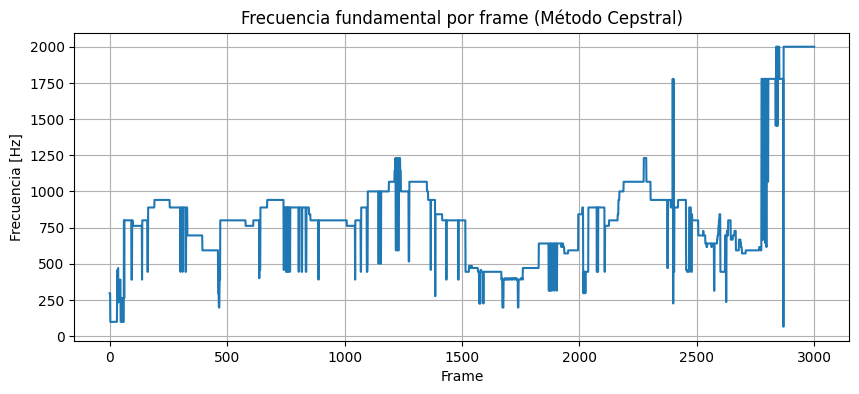

In [8]:
fn_full = np.concatenate(fn, axis=-1)

plt.figure(figsize=(10,4))
plt.plot(fn_full)
plt.title("Frecuencia fundamental por frame (Método Cepstral)")
plt.xlabel("Frame")
plt.ylabel("Frecuencia [Hz]")
plt.grid()
plt.show()

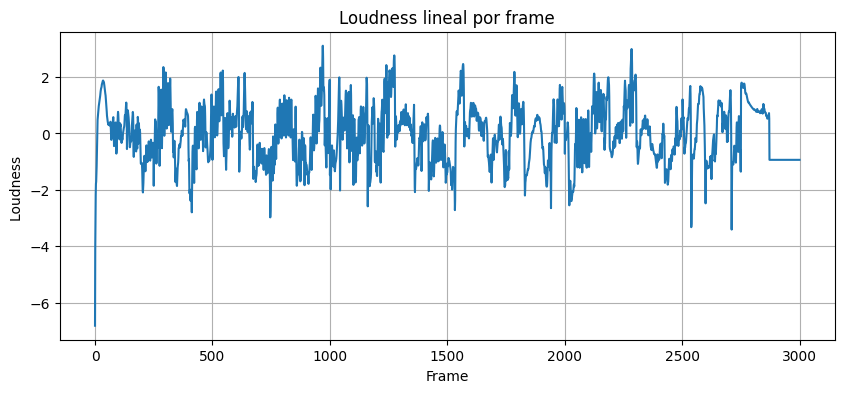

In [9]:
A = np.concatenate(ld, axis=-1)
A_db = np.concatenate(ld_db, axis=-1)
plt.figure(figsize=(10, 4))
plt.plot(A_db)
plt.title("Loudness lineal por frame")
plt.xlabel("Frame")
plt.ylabel("Loudness ")
plt.grid()
plt.show()

In [80]:
B, T, K = 1, fn_full.shape[0], 101
ks = np.arange(1, K + 1)[np.newaxis, np.newaxis, :]  # (1,1,K)
# decaimiento armónico ~ 1/k
harmonics = (1.0 / ks) * np.random.uniform(0.8, 1.2, (B, T, K))
harmonics = harmonics / np.sum(harmonics, axis=-1, keepdims=True)  # normalizar energía
harmonics = harmonics.astype(np.float32)

print(harmonics.shape)
print(harmonics[0][1])

(1, 3000, 101)
[0.2006462  0.11138204 0.07251593 0.04125714 0.03270911 0.02735422
 0.03179068 0.02684353 0.02039775 0.01547427 0.01984536 0.0159526
 0.0135892  0.01333419 0.01425839 0.01087291 0.00908648 0.01168572
 0.00908736 0.00763753 0.00735832 0.01012393 0.00862139 0.00730995
 0.00639481 0.00607005 0.00554706 0.00694205 0.00555538 0.00657317
 0.00653008 0.00532992 0.00521056 0.00514922 0.00568351 0.0046417
 0.00422275 0.00516382 0.0048956  0.00402487 0.0052427  0.00389486
 0.00366844 0.0036591  0.00473039 0.00402672 0.00468927 0.00456943
 0.00345826 0.00332725 0.00378926 0.00395557 0.00343641 0.00404566
 0.00286037 0.00396948 0.00266908 0.00366145 0.0037279  0.00312542
 0.00297341 0.00287568 0.003495   0.00253028 0.00233606 0.00261032
 0.00300035 0.00327494 0.00282103 0.00225087 0.00263079 0.00235919
 0.00237107 0.00224774 0.00286374 0.00199656 0.00231606 0.00251017
 0.00266939 0.00271612 0.00238998 0.00237551 0.00211801 0.00214143
 0.00237802 0.00221099 0.00252912 0.00235969 0.00

In [81]:
f0_tf   = tf.constant(fn_full, dtype=tf.float32)
loud_tf = tf.constant(A, dtype=tf.float32)
harm_tf = tf.constant(harmonics, dtype=tf.float32)

f0_tf = tf.expand_dims(f0_tf, 0)
f0_tf = tf.expand_dims(f0_tf, -1)
loud_tf = tf.expand_dims(loud_tf, 0)
loud_tf = tf.expand_dims(loud_tf, -1)


print(f0_tf.shape)     # (1, 250, 1)
print(loud_tf.shape)   # (1, 250, 1)
print(harm_tf.shape)   # (1, 250, 101)


(1, 3000, 1)
(1, 3000, 1)
(1, 3000, 101)


In [85]:
def additive_synth(f0, loudness, harmonics):
    """
    f0:     (B, T, 1)
    loud:   (B, T, 1)
    harm:   (B, T, K)
    Devuelve: audio (B, N)
    """
    B = tf.shape(f0)[0]
    T = tf.shape(f0)[1]
    K = tf.shape(harmonics)[2]
    N = 734455
    sr = 16000
    # Upsampling a tasa de audio (ceil y recorte a N para evitar supuestos)
    reps = tf.cast(tf.math.ceil(tf.cast(N, tf.float32) / tf.cast(T, tf.float32)), tf.int32)
    f0_up   = tf.repeat(f0,   repeats=reps, axis=1)[:, :N, :]        # (B,N,1)
    loud_up = tf.repeat(loudness, repeats=reps, axis=1)[:, :N, :]    # (B,N,1)
    harm_up = tf.repeat(harmonics, repeats=reps, axis=1)[:, :N, :]   # (B,N,K)
    #noise_up = tf.repeat(noise, repeats=reps, axis=1)[:, :N, :]     # (B,N,65)
    # Fase acumulada: phi[n] = sum_{m<=n} 2*pi*f0[m]/fs
    omega = 2.0 * tf.constant(np.pi, tf.float32) * f0_up[..., 0] / float(sr)  # (B,N)
    phi = tf.cumsum(omega, axis=1)                                   # (B,N)
    phi = phi[:, :, tf.newaxis]                                      # (B,N,1)
    # Índices de armónicos k = 1..K
    ks = tf.reshape(tf.range(1, tf.cast(K, tf.int32) + 1, dtype=tf.float32), (1, 1, -1))  # (1,1,K)
    # Señal por armónico y suma final
    phase = phi * ks                             # (B,N,K)
    sig = loud_up * harm_up * tf.sin(phase)     # (B,N,K)
    audio_harm = tf.reduce_sum(sig, axis=-1)         # (B,N)
    
    return audio_harm

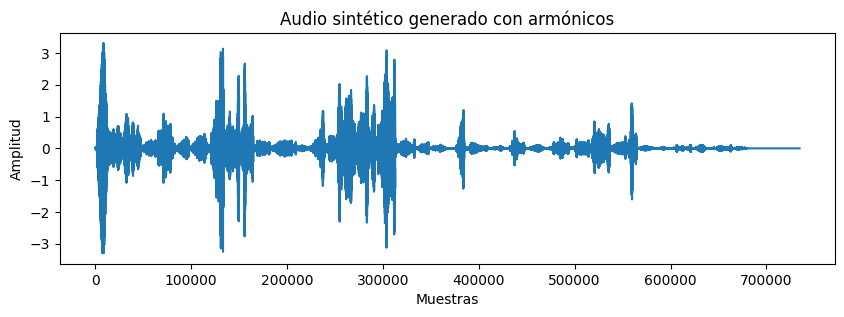

In [86]:
audio = additive_synth(f0_tf, loud_tf, harm_tf)

# Convertir a numpy y graficar
audio_np = audio.numpy()[0]
plt.figure(figsize=(10,3))
plt.plot(audio_np)
plt.title("Audio sintético generado con armónicos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

In [87]:
import soundfile as sf
sf.write("borrar.wav", audio_np, 16000)

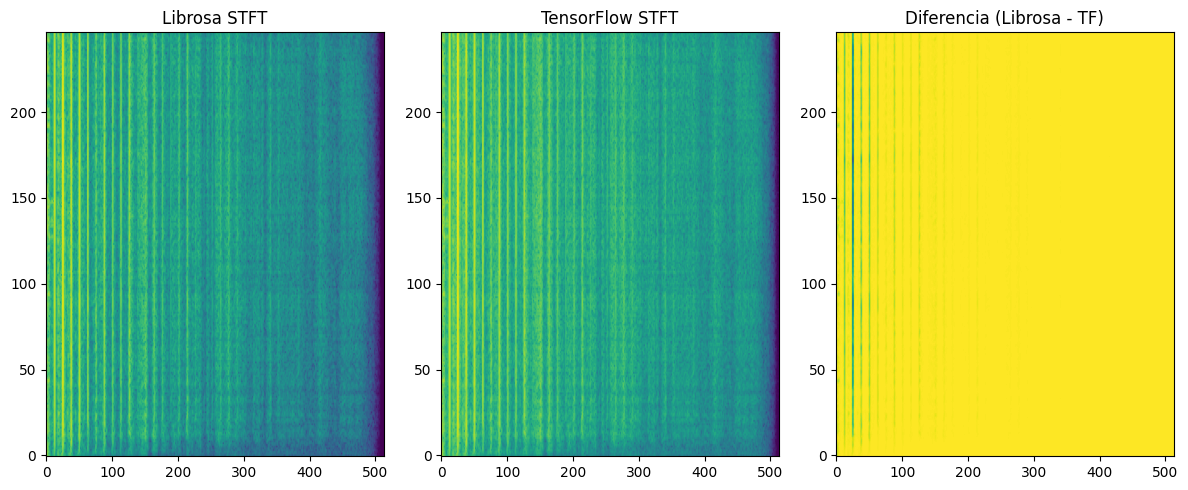

tf.Tensor(2.2763815, shape=(), dtype=float32)


In [130]:
sr = 16000
data = np.load('SampLib_DPA_01_Seg0.npz')
x = data['audio']
x_tf = tf.constant(x)
# STFT con librosa
n_fft = 1024
hop_length = 256
stft_librosa = tf.signal.stft(x_tf, frame_length=n_fft, frame_step=hop_length, fft_length=n_fft)
mag_librosa = tf.abs(stft_librosa) + 1e-6

# STFT con tensorflow
stft_tf = tf.signal.stft(10*x_tf, frame_length=n_fft, frame_step=hop_length, fft_length=n_fft)
mag_tf = tf.abs(stft_tf) + 1e-6 # Transponer para coincidir con librosa

# Plotear ambas magnitudes
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(tf.math.log(mag_librosa), aspect='auto', origin='lower')
plt.title('Librosa STFT')
plt.subplot(1, 3, 2)
plt.imshow(tf.math.log(mag_tf), aspect='auto', origin='lower')
plt.title('TensorFlow STFT')
plt.subplot(1, 3, 3)
plt.imshow(mag_librosa- mag_tf, aspect='auto', origin='lower')
plt.title('Diferencia (Librosa - TF)')
plt.tight_layout()
plt.show()

print(tf.reduce_mean(tf.abs(tf.math.log(mag_librosa) - tf.math.log(mag_tf))))

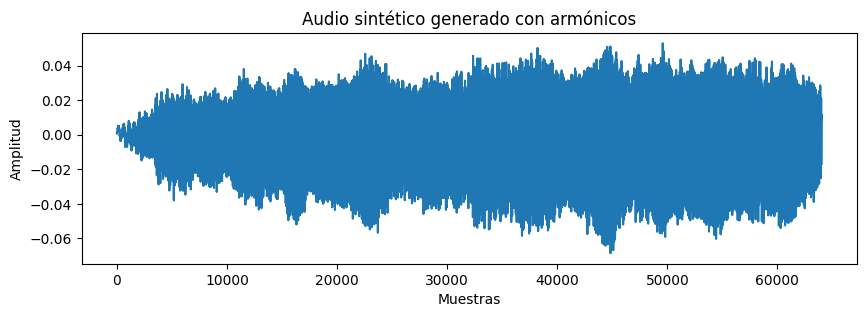

In [129]:
plt.figure(figsize=(10,3))
plt.plot(5*x_tf)
plt.title("Audio sintético generado con armónicos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()